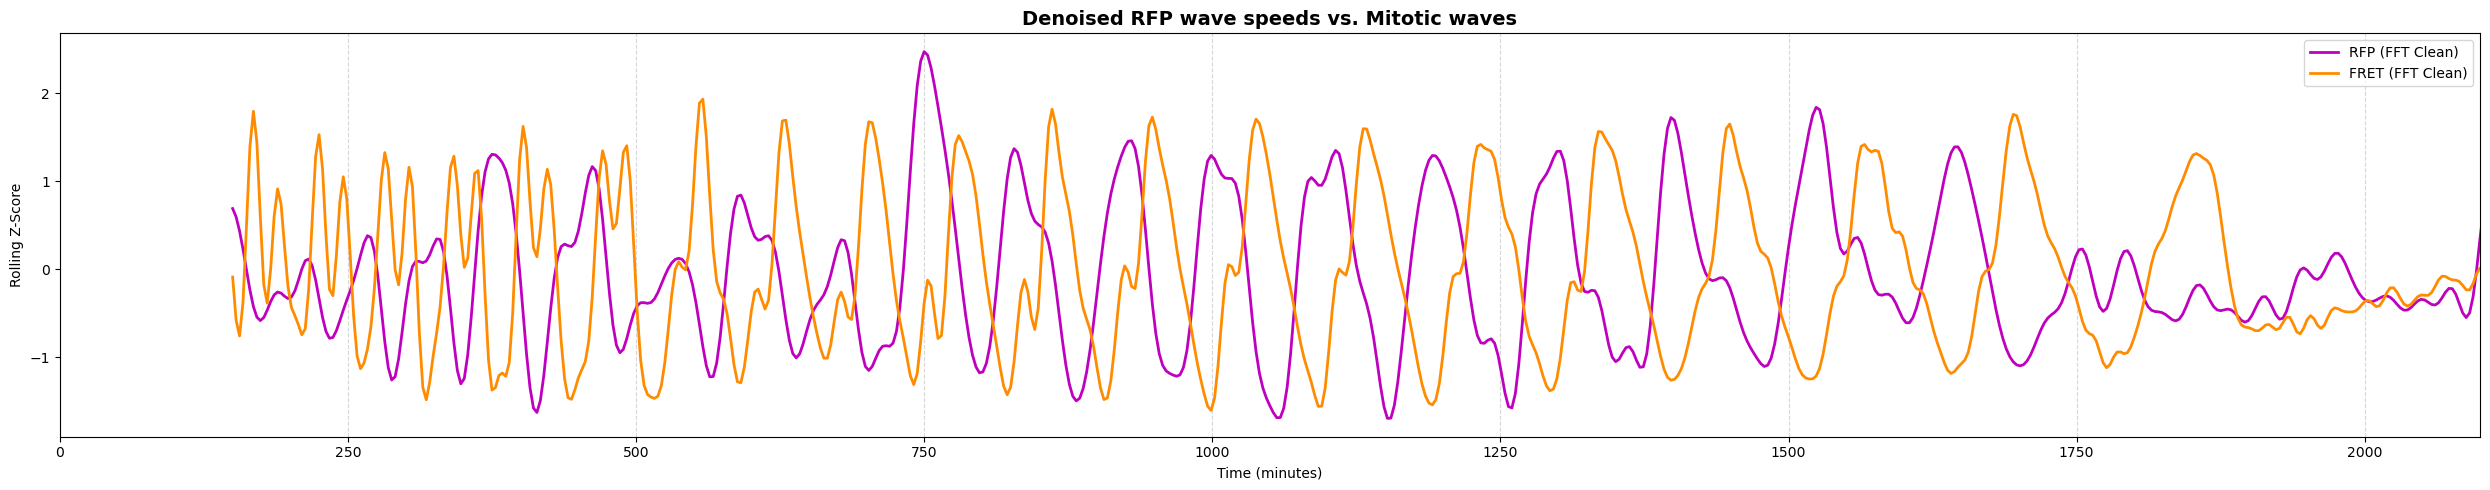

In [6]:
import pandas as pd                 
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import argrelextrema

#normalization parameters, I am using Zscore for ftt
def rolling_zscore(series, window):
    rolling_mean = series.rolling(window=window, center=True).mean()
    rolling_std = series.rolling(window=window, center=True).std()
    return (series - rolling_mean) / rolling_std

#path stuff
PATH = '~/Library/Mobile Documents/com~apple~CloudDocs/Desktop/'
FILENAME_POS9_Mech = 'velocity_analyticsRFPPOS9algo.csv'
FILENAME_POS9_Mito = 'wave_source_analytics_POS9FRETCFP.csv'
#declaring data
dataMech = pd.read_csv(PATH + FILENAME_POS9_Mech, sep=',')
dataMito = pd.read_csv(PATH + FILENAME_POS9_Mito, sep=',')
TimeMech = dataMech['Time']
ActivityMech = dataMech['Avg_Speed']
TimeMito = dataMito['Time(min)'] 
ActivityMito = dataMito['GlobalWaveActivityMetric']
#XkymoMito = dataMito['kymoxwave']

#I did this bc otherwise it gets mad :(
window_frames = int(300 / 3.0) 

#Normalizing the data 
norm_ActivityMech = rolling_zscore(ActivityMech, window_frames)
norm_ActivityMito = rolling_zscore(ActivityMito, window_frames)
#norm_Activityxkymo = rolling_zscore(XkymoMito, window_frames)

#FFT denoising stuff
def fft_denoise(signal, threshold_percent=.05):
    fft_vals = np.fft.fft(signal)
    power = np.abs(fft_vals) ** 2
    max_power = np.max(power)
    threshold = threshold_percent * max_power
    fft_vals_clean = fft_vals.copy()
    fft_vals_clean[power < threshold] = 0
    return np.fft.ifft(fft_vals_clean).real

#cleaning up the noise and 'threshold_percent' affects the damping
clean_ActivityMech = fft_denoise(norm_ActivityMech.dropna(), threshold_percent=0.045)
clean_ActivityMito = fft_denoise(norm_ActivityMito.dropna(), threshold_percent=0.009)
#clean_ActivityMito = fft_denoise(norm_Activityxkymo.dropna(), threshold_percent=0.009)

#getting rid of time data that it's corresponding activity data was dropped
clean_TimeMech = TimeMech[norm_ActivityMech.notna()].reset_index(drop=True)
clean_TimeMito = TimeMito[norm_ActivityMito.notna()].reset_index(drop=True)
#clean_Timexkymo = TimexMito[norm_Activityxkymo.notna()].reset_index(drop=True)

#Plots
plt.figure(figsize=(25, 5))
plt.title('Denoised RFP wave speeds vs. Mitotic waves', fontsize=14, fontweight='bold')
plt.plot(clean_TimeMech, clean_ActivityMech, linestyle="-", color="m", linewidth=2, label='RFP (FFT Clean)')
plt.plot(clean_TimeMito, clean_ActivityMito, linestyle="-", color="darkorange", linewidth=2, label='FRET (FFT Clean)')
plt.xlabel('Time (minutes)')
plt.ylabel('Rolling Z-Score')
plt.xlim(0, 2100) 
plt.legend(loc="upper right")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#finding the local peaks 
max_indMECH = argrelextrema(clean_ActivityMech, np.greater)[0]
max_indMITO = argrelextrema(clean_ActivityMito, np.greater)[0]
Mechmaxpts = clean_ActivityMech[max_indMECH]
Mitomaxpts = clean_ActivityMito[max_indMITO]

In [2]:
#POS10

#path stuff
PATH = '~/Library/Mobile Documents/com~apple~CloudDocs/Desktop/'
FILENAME_POS10_Mech = 'velocity_analyticsRFPPOS10algo.csv'
FILENAME_POS10_Mito = 'wave_source_analytics_POS10FRETCFP.csv'
#declaring data
dataMech10 = pd.read_csv(PATH + FILENAME_POS10_Mech, sep=',')
dataMito10 = pd.read_csv(PATH + FILENAME_POS10_Mito, sep=',')
TimeMech10 = dataMech10['Time']
ActivityMech10 = dataMech10['Avg_Speed']
TimeMito10 = dataMito10['Time(min)'] 
ActivityMito10 = dataMito10['GlobalWaveActivityMetric']

#I did this bc otherwise it gets mad :(
window_frames = int(300 / 3.0) 

#Normalizing the data 
norm_ActivityMech10 = rolling_zscore(ActivityMech10, window_frames)
norm_ActivityMito10 = rolling_zscore(ActivityMito10, window_frames)

#FFT denoising stuff
def fft_denoise(signal10, threshold_percent10=.05):
    fft_vals10 = np.fft.fft(signal10)
    power10 = np.abs(fft_vals10) ** 2
    max_power10 = np.max(power10)
    threshold10 = threshold_percent10 * max_power10
    fft_vals_clean10 = fft_vals10.copy()
    fft_vals_clean10[power10 < threshold10] = 0
    return np.fft.ifft(fft_vals_clean10).real

#cleaning up the noise and 'threshold_percent' affects the damping
clean_ActivityMech10 = fft_denoise(norm_ActivityMech10.dropna(), threshold_percent10=0.06)
clean_ActivityMito10 = fft_denoise(norm_ActivityMito10.dropna(), threshold_percent10=0.009)

#getting rid of time data that it's corresponding activity data was dropped
clean_TimeMech10 = TimeMech10[norm_ActivityMech10.notna()].reset_index(drop=True)
clean_TimeMito10 = TimeMito10[norm_ActivityMito10.notna()].reset_index(drop=True)

#Plots
plt.figure(figsize=(25, 5))
plt.title('Denoised RFP wave speeds vs. Mitotic waves', fontsize=14, fontweight='bold')
plt.plot(clean_TimeMech10, clean_ActivityMech10, linestyle="-", color="m", linewidth=2, label='RFP (FFT Clean)')
plt.plot(clean_TimeMito10, clean_ActivityMito10, linestyle="-", color="darkorange", linewidth=2, label='FRET (FFT Clean)')
plt.xlabel('Time (minutes)')
plt.ylabel('Relative Magnitude')
plt.xlim(0, 2100) 
plt.legend(loc="upper right")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#finding teh local peaks 
max_indMECH10 = argrelextrema(clean_ActivityMech10, np.greater)[0]
max_indMITO10 = argrelextrema(clean_ActivityMito10, np.greater)[0]
Mechmaxpts10 = clean_ActivityMech10[max_indMECH10]
Mitomaxpts10 = clean_ActivityMito10[max_indMITO10]

#Printing that info for analysis later 
print("RFP Mechanical Peaks:")
for t, val in zip(clean_TimeMech10.iloc[max_indMECH10], Mechmaxpts10):
    print(f"Time: {t:.2f} min | Value: {val:.4f}")

print("\nFRET Mitotic Peaks:")
for t, val in zip(clean_TimeMito10.iloc[max_indMITO10], Mitomaxpts10):
    print(f"Time: {t:.2f} min | Value: {val:.4f}")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/maggie/Library/Mobile Documents/com~apple~CloudDocs/Desktop/velocity_analyticsRFPPOS10algo.csv'

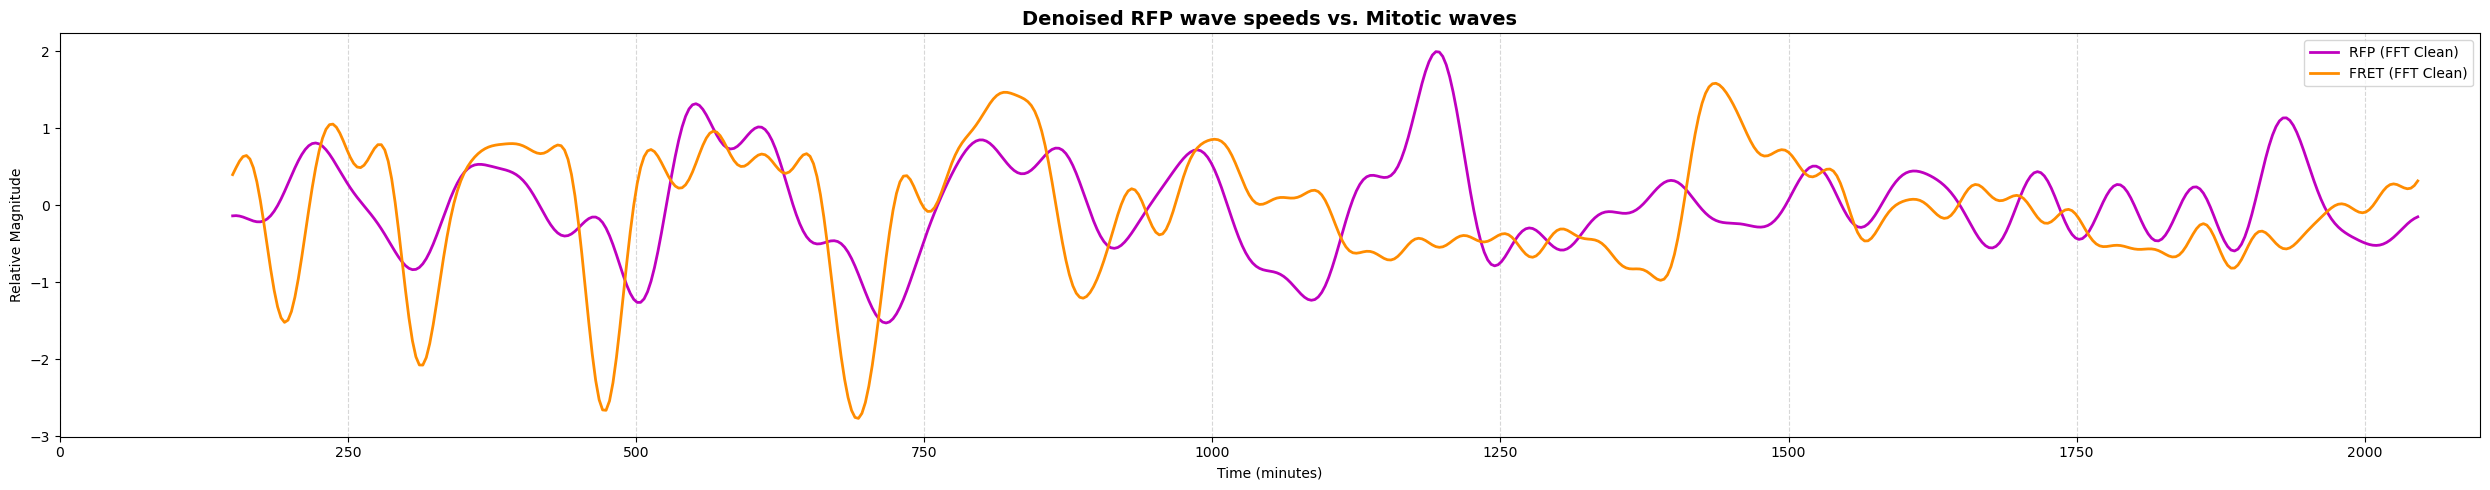

RFP Mechanical Peaks:
Time: 153.00 min | Value: -0.1357
Time: 222.00 min | Value: 0.8072
Time: 363.00 min | Value: 0.5297
Time: 465.00 min | Value: -0.1544
Time: 552.00 min | Value: 1.3167
Time: 606.00 min | Value: 1.0152
Time: 672.00 min | Value: -0.4614
Time: 798.00 min | Value: 0.8468
Time: 864.00 min | Value: 0.7405
Time: 987.00 min | Value: 0.7179
Time: 1140.00 min | Value: 0.3872
Time: 1194.00 min | Value: 1.9922
Time: 1275.00 min | Value: -0.2957
Time: 1344.00 min | Value: -0.0839
Time: 1398.00 min | Value: 0.3217
Time: 1521.00 min | Value: 0.5063
Time: 1608.00 min | Value: 0.4434
Time: 1716.00 min | Value: 0.4350
Time: 1785.00 min | Value: 0.2682
Time: 1854.00 min | Value: 0.2371
Time: 1932.00 min | Value: 1.1333

FRET Mitotic Peaks:
Time: 162.00 min | Value: 0.6443
Time: 237.00 min | Value: 1.0518
Time: 279.00 min | Value: 0.7850
Time: 393.00 min | Value: 0.7989
Time: 432.00 min | Value: 0.7809
Time: 513.00 min | Value: 0.7222
Time: 567.00 min | Value: 0.9604
Time: 609.00 min 

In [34]:
#POS11
#path stuff
PATH = '~/Library/Mobile Documents/com~apple~CloudDocs/Desktop/'
FILENAME_POS11_Mech = 'velocity_analyticsRFPPOS11algo.csv'
FILENAME_POS11_Mito = 'wave_source_analytics_POS11FRETCFP.csv'
#declaring data
dataMech11 = pd.read_csv(PATH + FILENAME_POS11_Mech, sep=',')
dataMito11 = pd.read_csv(PATH + FILENAME_POS11_Mito, sep=',')
TimeMech11 = dataMech11['Time']
ActivityMech11 = dataMech11['Avg_Speed']
TimeMito11 = dataMito11['Time(min)'] 
ActivityMito11 = dataMito11['GlobalWaveActivityMetric']

#I did this bc otherwise it gets mad :(
window_frames = int(300 / 3.0) 

#Normalizing the data 
norm_ActivityMech11 = rolling_zscore(ActivityMech11, window_frames)
norm_ActivityMito11 = rolling_zscore(ActivityMito11, window_frames)

#FFT denoising stuff
def fft_denoise(signal11, threshold_percent11=.05):
    fft_vals11 = np.fft.fft(signal11)
    power11 = np.abs(fft_vals11) ** 2
    max_power11 = np.max(power11)
    threshold11 = threshold_percent11 * max_power11
    fft_vals_clean11 = fft_vals11.copy()
    fft_vals_clean11[power11 < threshold11] = 0
    return np.fft.ifft(fft_vals_clean11).real

#cleaning up the noise and 'threshold_percent' affects the damping
clean_ActivityMech11 = fft_denoise(norm_ActivityMech11.dropna(), threshold_percent11=0.077)
clean_ActivityMito11 = fft_denoise(norm_ActivityMito11.dropna(), threshold_percent11=0.025)

#getting rid of time data that it's corresponding activity data was dropped
clean_TimeMech11 = TimeMech11[norm_ActivityMech11.notna()].reset_index(drop=True)
clean_TimeMito11 = TimeMito11[norm_ActivityMito11.notna()].reset_index(drop=True)

#Plots
plt.figure(figsize=(25, 5))
plt.title('Denoised RFP wave speeds vs. Mitotic waves', fontsize=14, fontweight='bold')
plt.plot(clean_TimeMech11, clean_ActivityMech11, linestyle="-", color="m", linewidth=2, label='RFP (FFT Clean)')
plt.plot(clean_TimeMito11, clean_ActivityMito11, linestyle="-", color="darkorange", linewidth=2, label='FRET (FFT Clean)')
plt.xlabel('Time (minutes)')
plt.ylabel('Relative Magnitude')
plt.xlim(0, 2100) 
plt.legend(loc="upper right")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#finding teh local peaks 
max_indMECH11 = argrelextrema(clean_ActivityMech11, np.greater)[0]
max_indMITO11 = argrelextrema(clean_ActivityMito11, np.greater)[0]
Mechmaxpts11 = clean_ActivityMech11[max_indMECH11]
Mitomaxpts11 = clean_ActivityMito11[max_indMITO11]

#Printing that info for analysis later 
print("RFP Mechanical Peaks:")
for t, val in zip(clean_TimeMech11.iloc[max_indMECH11], Mechmaxpts11):
    print(f"Time: {t:.2f} min | Value: {val:.4f}")

print("\nFRET Mitotic Peaks:")
for t, val in zip(clean_TimeMito11.iloc[max_indMITO11], Mitomaxpts11):
    print(f"Time: {t:.2f} min | Value: {val:.4f}")

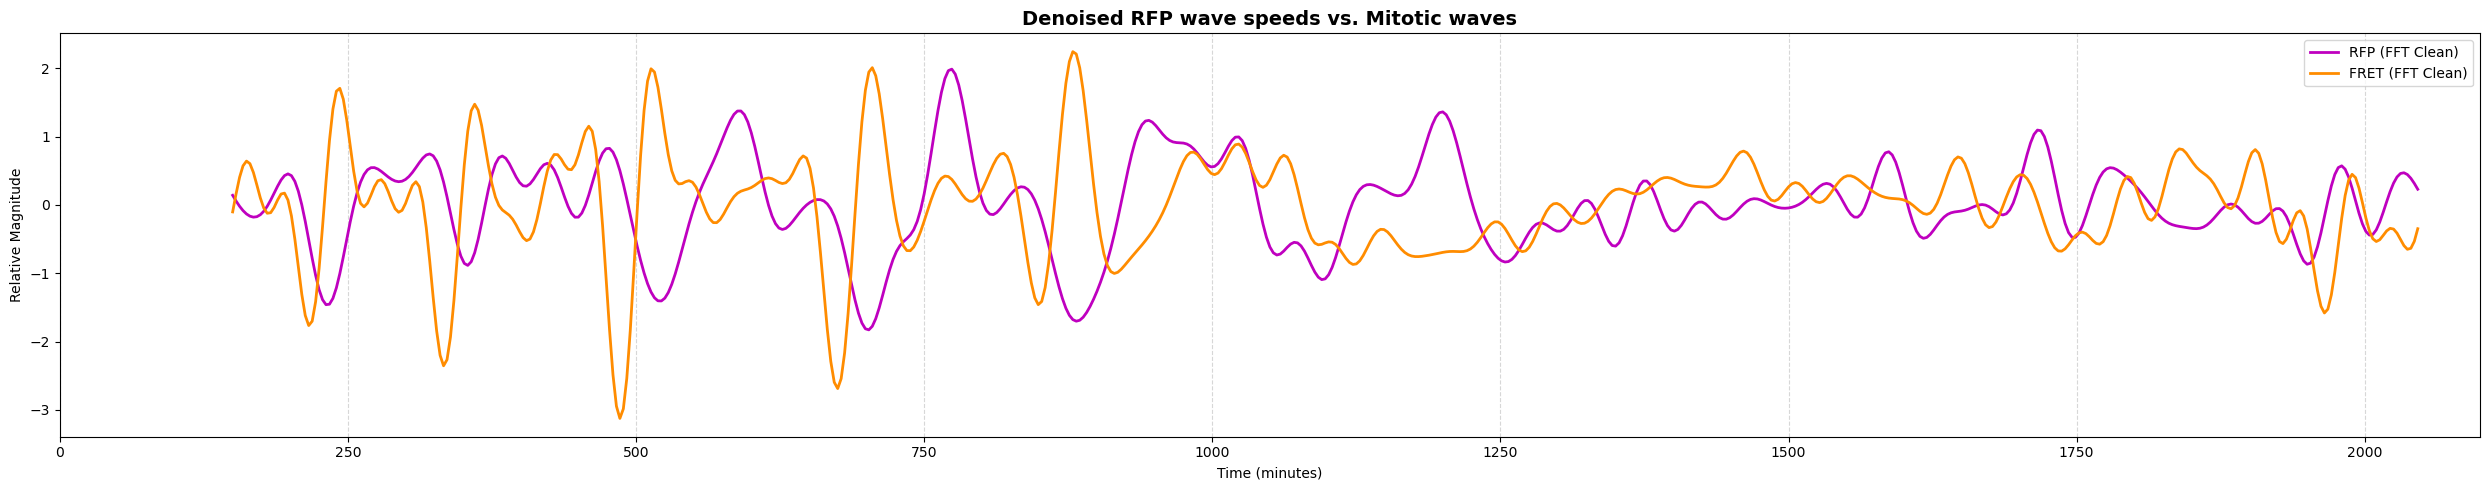

RFP Mechanical Peaks:
Time: 198.00 min | Value: 0.4549
Time: 273.00 min | Value: 0.5466
Time: 321.00 min | Value: 0.7469
Time: 384.00 min | Value: 0.7167
Time: 423.00 min | Value: 0.6092
Time: 477.00 min | Value: 0.8284
Time: 591.00 min | Value: 1.3758
Time: 657.00 min | Value: 0.0784
Time: 774.00 min | Value: 1.9885
Time: 834.00 min | Value: 0.2660
Time: 945.00 min | Value: 1.2383
Time: 1023.00 min | Value: 0.9958
Time: 1071.00 min | Value: -0.5477
Time: 1137.00 min | Value: 0.2991
Time: 1200.00 min | Value: 1.3627
Time: 1284.00 min | Value: -0.2629
Time: 1326.00 min | Value: 0.0646
Time: 1377.00 min | Value: 0.3508
Time: 1425.00 min | Value: 0.0423
Time: 1470.00 min | Value: 0.0916
Time: 1533.00 min | Value: 0.3155
Time: 1587.00 min | Value: 0.7785
Time: 1668.00 min | Value: 0.0056
Time: 1716.00 min | Value: 1.0961
Time: 1779.00 min | Value: 0.5455
Time: 1884.00 min | Value: 0.0137
Time: 1926.00 min | Value: -0.0531
Time: 1980.00 min | Value: 0.5726
Time: 2034.00 min | Value: 0.4711


In [42]:
#POS12
#path stuff
PATH = '~/Library/Mobile Documents/com~apple~CloudDocs/Desktop/'
FILENAME_POS12_Mech = 'velocity_analyticsRFPPOS12algo.csv'
FILENAME_POS12_Mito = 'wave_source_analytics_POS12FRETCFP.csv'
#declaring data
dataMech12 = pd.read_csv(PATH + FILENAME_POS12_Mech, sep=',')
dataMito12 = pd.read_csv(PATH + FILENAME_POS12_Mito, sep=',')
TimeMech12 = dataMech12['Time']
ActivityMech12 = dataMech12['Avg_Speed']
TimeMito12 = dataMito12['Time(min)'] 
ActivityMito12 = dataMito12['GlobalWaveActivityMetric']

#I did this bc otherwise it gets mad :(
window_frames = int(300 / 3.0) 

#Normalizing the data 
norm_ActivityMech12 = rolling_zscore(ActivityMech12, window_frames)
norm_ActivityMito12 = rolling_zscore(ActivityMito12, window_frames)

#FFT denoising stuff
def fft_denoise(signal12, threshold_percent12=.05):
    fft_vals12 = np.fft.fft(signal12)
    power12 = np.abs(fft_vals12) ** 2
    max_power12 = np.max(power12)
    threshold12 = threshold_percent12 * max_power12
    fft_vals_clean12 = fft_vals12.copy()
    fft_vals_clean12[power12 < threshold12] = 0
    return np.fft.ifft(fft_vals_clean12).real

#cleaning up the noise and 'threshold_percent' affects the damping
clean_ActivityMech12 = fft_denoise(norm_ActivityMech12.dropna(), threshold_percent12=0.077)
clean_ActivityMito12 = fft_denoise(norm_ActivityMito12.dropna(), threshold_percent12=0.1)

#getting rid of time data that it's corresponding activity data was dropped
clean_TimeMech12 = TimeMech12[norm_ActivityMech12.notna()].reset_index(drop=True)
clean_TimeMito12 = TimeMito12[norm_ActivityMito12.notna()].reset_index(drop=True)

#Plots
plt.figure(figsize=(25, 5))
plt.title('Denoised RFP wave speeds vs. Mitotic waves', fontsize=14, fontweight='bold')
plt.plot(clean_TimeMech12, clean_ActivityMech12, linestyle="-", color="m", linewidth=2, label='RFP (FFT Clean)')
plt.plot(clean_TimeMito12, clean_ActivityMito12, linestyle="-", color="darkorange", linewidth=2, label='FRET (FFT Clean)')
plt.xlabel('Time (minutes)')
plt.ylabel('Relative Magnitude')
plt.xlim(0, 2100) 
plt.legend(loc="upper right")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#finding teh local peaks 
max_indMECH12 = argrelextrema(clean_ActivityMech12, np.greater)[0]
max_indMITO12 = argrelextrema(clean_ActivityMito12, np.greater)[0]
Mechmaxpts12 = clean_ActivityMech12[max_indMECH12]
Mitomaxpts12 = clean_ActivityMito12[max_indMITO12]

#Printing that info for analysis later 
print("RFP Mechanical Peaks:")
for t, val in zip(clean_TimeMech12.iloc[max_indMECH12], Mechmaxpts12):
    print(f"Time: {t:.2f} min | Value: {val:.4f}")

print("\nFRET Mitotic Peaks:")
for t, val in zip(clean_TimeMito12.iloc[max_indMITO12], Mitomaxpts12):
    print(f"Time: {t:.2f} min | Value: {val:.4f}")

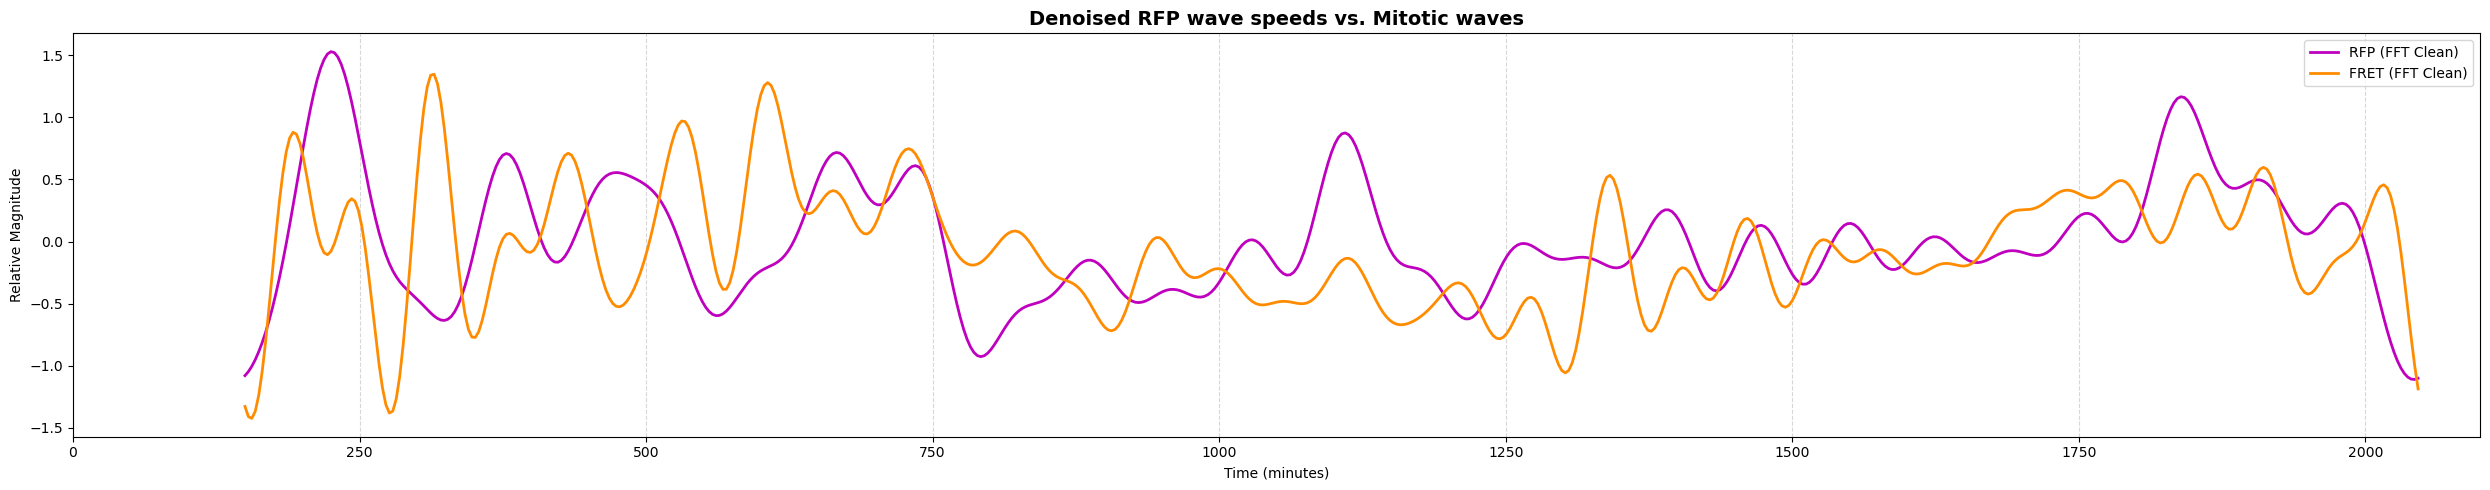

RFP Mechanical Peaks:
Time: 225.00 min | Value: 1.5275
Time: 378.00 min | Value: 0.7081
Time: 474.00 min | Value: 0.5549
Time: 666.00 min | Value: 0.7164
Time: 735.00 min | Value: 0.6103
Time: 888.00 min | Value: -0.1502
Time: 960.00 min | Value: -0.3850
Time: 1029.00 min | Value: 0.0137
Time: 1110.00 min | Value: 0.8737
Time: 1266.00 min | Value: -0.0156
Time: 1317.00 min | Value: -0.1263
Time: 1392.00 min | Value: 0.2549
Time: 1473.00 min | Value: 0.1302
Time: 1551.00 min | Value: 0.1458
Time: 1623.00 min | Value: 0.0379
Time: 1692.00 min | Value: -0.0735
Time: 1758.00 min | Value: 0.2267
Time: 1839.00 min | Value: 1.1648
Time: 1905.00 min | Value: 0.4962
Time: 1980.00 min | Value: 0.3078

FRET Mitotic Peaks:
Time: 192.00 min | Value: 0.8795
Time: 243.00 min | Value: 0.3442
Time: 315.00 min | Value: 1.3459
Time: 381.00 min | Value: 0.0658
Time: 432.00 min | Value: 0.7103
Time: 531.00 min | Value: 0.9695
Time: 606.00 min | Value: 1.2785
Time: 663.00 min | Value: 0.4094
Time: 729.00 mi

In [49]:
#POS13
#path stuff
PATH = '~/Library/Mobile Documents/com~apple~CloudDocs/Desktop/'
FILENAME_POS13_Mech = 'velocity_analyticsRFPPOS13algo.csv'
FILENAME_POS13_Mito = 'wave_source_analytics_POS13FRETCFP.csv'
#declaring data
dataMech13 = pd.read_csv(PATH + FILENAME_POS13_Mech, sep=',')
dataMito13 = pd.read_csv(PATH + FILENAME_POS13_Mito, sep=',')
TimeMech13 = dataMech13['Time']
ActivityMech13 = dataMech13['Avg_Speed']
TimeMito13 = dataMito13['Time(min)'] 
ActivityMito13 = dataMito13['GlobalWaveActivityMetric']

#I did this bc otherwise it gets mad :(
window_frames = int(300 / 3.0) 

#Normalizing the data 
norm_ActivityMech13 = rolling_zscore(ActivityMech13, window_frames)
norm_ActivityMito13 = rolling_zscore(ActivityMito13, window_frames)

#FFT denoising stuff
def fft_denoise(signal13, threshold_percent13=.05):
    fft_vals13 = np.fft.fft(signal13)
    power13 = np.abs(fft_vals13) ** 2
    max_power13 = np.max(power13)
    threshold13 = threshold_percent13 * max_power13
    fft_vals_clean13 = fft_vals13.copy()
    fft_vals_clean13[power13 < threshold13] = 0
    return np.fft.ifft(fft_vals_clean13).real

#cleaning up the noise and 'threshold_percent' affects the damping
clean_ActivityMech13 = fft_denoise(norm_ActivityMech13.dropna(), threshold_percent13=0.22)
clean_ActivityMito13 = fft_denoise(norm_ActivityMito13.dropna(), threshold_percent13=0.12)

#getting rid of time data that it's corresponding activity data was dropped
clean_TimeMech13 = TimeMech13[norm_ActivityMech13.notna()].reset_index(drop=True)
clean_TimeMito13 = TimeMito13[norm_ActivityMito13.notna()].reset_index(drop=True)

#Plots
plt.figure(figsize=(25, 5))
plt.title('Denoised RFP wave speeds vs. Mitotic waves', fontsize=14, fontweight='bold')
plt.plot(clean_TimeMech13, clean_ActivityMech13, linestyle="-", color="m", linewidth=2, label='RFP (FFT Clean)')
plt.plot(clean_TimeMito13, clean_ActivityMito13, linestyle="-", color="darkorange", linewidth=2, label='FRET (FFT Clean)')
plt.xlabel('Time (minutes)')
plt.ylabel('Relative Magnitude')
plt.xlim(0, 2100) 
plt.legend(loc="upper right")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#finding teh local peaks 
max_indMECH13 = argrelextrema(clean_ActivityMech13, np.greater)[0]
max_indMITO13 = argrelextrema(clean_ActivityMito13, np.greater)[0]
Mechmaxpts13 = clean_ActivityMech13[max_indMECH13]
Mitomaxpts13 = clean_ActivityMito13[max_indMITO13]

#Printing that info for analysis later 
print("RFP Mechanical Peaks:")
for t, val in zip(clean_TimeMech13.iloc[max_indMECH13], Mechmaxpts13):
    print(f"Time: {t:.2f} min | Value: {val:.4f}")

print("\nFRET Mitotic Peaks:")
for t, val in zip(clean_TimeMito13.iloc[max_indMITO13], Mitomaxpts13):
    print(f"Time: {t:.2f} min | Value: {val:.4f}")

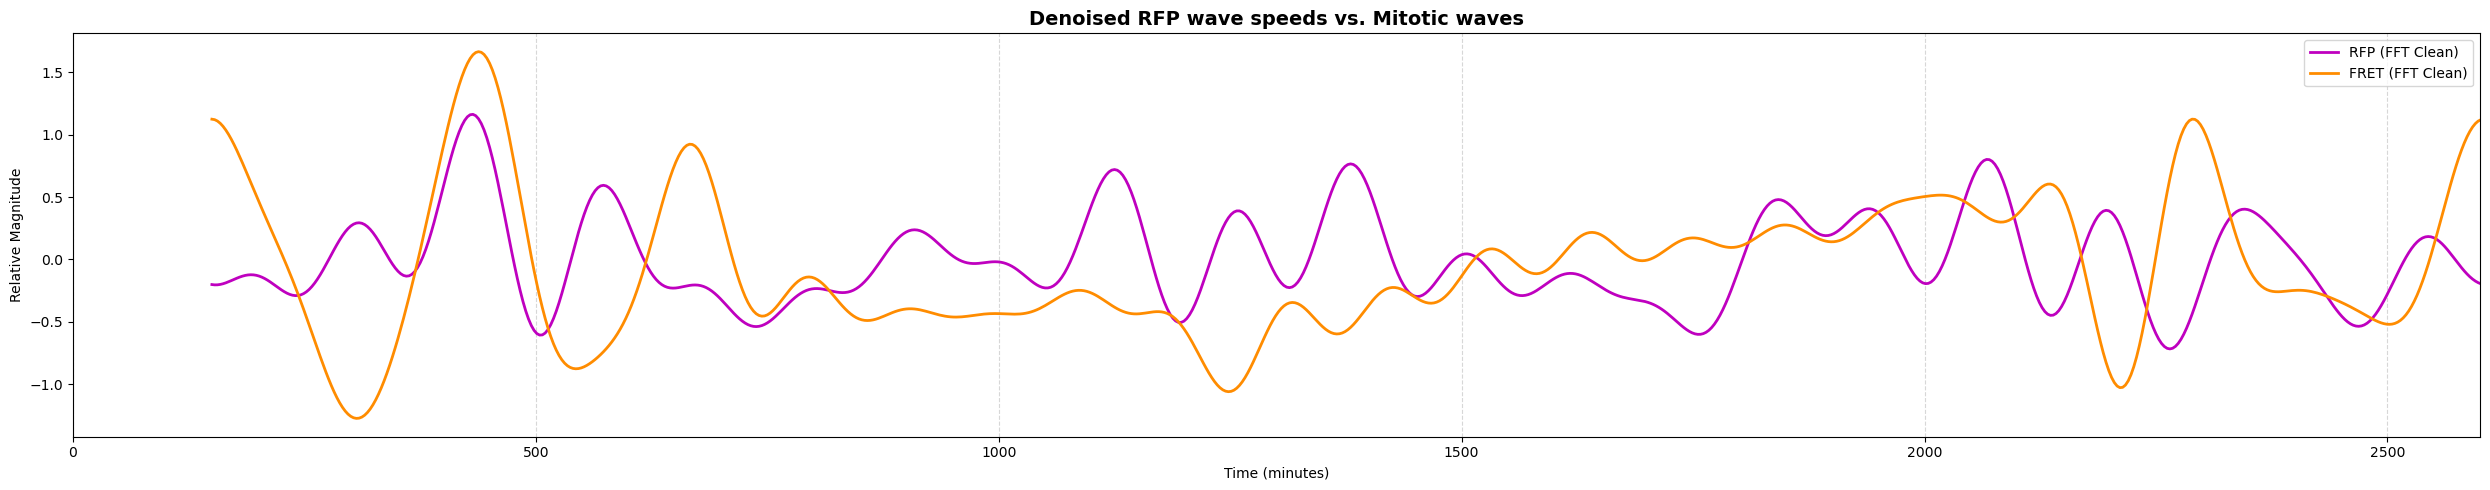

RFP Mechanical Peaks:
Time: 192.00 min | Value: -0.1221
Time: 309.00 min | Value: 0.2940
Time: 432.00 min | Value: 1.1620
Time: 573.00 min | Value: 0.5940
Time: 672.00 min | Value: -0.2039
Time: 804.00 min | Value: -0.2327
Time: 909.00 min | Value: 0.2378
Time: 996.00 min | Value: -0.0180
Time: 1125.00 min | Value: 0.7203
Time: 1257.00 min | Value: 0.3891
Time: 1380.00 min | Value: 0.7655
Time: 1506.00 min | Value: 0.0450
Time: 1617.00 min | Value: -0.1111
Time: 1842.00 min | Value: 0.4797
Time: 1941.00 min | Value: 0.4062
Time: 2067.00 min | Value: 0.8011
Time: 2196.00 min | Value: 0.3937
Time: 2346.00 min | Value: 0.4029
Time: 2544.00 min | Value: 0.1839

FRET Mitotic Peaks:
Time: 438.00 min | Value: 1.6640
Time: 666.00 min | Value: 0.9230
Time: 795.00 min | Value: -0.1397
Time: 903.00 min | Value: -0.3947
Time: 996.00 min | Value: -0.4328
Time: 1086.00 min | Value: -0.2469
Time: 1173.00 min | Value: -0.4175
Time: 1317.00 min | Value: -0.3440
Time: 1425.00 min | Value: -0.2241
Time: 

In [79]:
#POS14
#path stuff
PATH = '~/Library/Mobile Documents/com~apple~CloudDocs/Desktop/'
FILENAME_POS14_Mech = 'velocity_analyticsRFPPOS14algo2.csv'
FILENAME_POS14_Mito = 'wave_source_analytics_POS14FRETCFP2.csv'
#declaring data
dataMech14 = pd.read_csv(PATH + FILENAME_POS14_Mech, sep=',')
dataMito14 = pd.read_csv(PATH + FILENAME_POS14_Mito, sep=',')
TimeMech14 = dataMech14['Time']
ActivityMech14 = dataMech14['Avg_Speed']
TimeMito14 = dataMito14['Time(min)'] 
ActivityMito14 = dataMito14['GlobalWaveActivityMetric']

#I did this bc otherwise it gets mad :(
window_frames = int(300 / 3.0) 

#Normalizing the data 
norm_ActivityMech14 = rolling_zscore(ActivityMech14, window_frames)
norm_ActivityMito14 = rolling_zscore(ActivityMito14, window_frames)

#FFT denoising stuff
def fft_denoise(signal14, threshold_percent14=.05):
    fft_vals14 = np.fft.fft(signal14)
    power14 = np.abs(fft_vals14) ** 2
    max_power14 = np.max(power14)
    threshold14 = threshold_percent14 * max_power14
    fft_vals_clean14 = fft_vals14.copy()
    fft_vals_clean14[power14 < threshold14] = 0
    return np.fft.ifft(fft_vals_clean14).real

#cleaning up the noise and 'threshold_percent' affects the damping
clean_ActivityMech14 = fft_denoise(norm_ActivityMech14.dropna(), threshold_percent14=0.375)
clean_ActivityMito14 = fft_denoise(norm_ActivityMito14.dropna(), threshold_percent14=0.068)

#getting rid of time data that it's corresponding activity data was dropped
clean_TimeMech14 = TimeMech14[norm_ActivityMech14.notna()].reset_index(drop=True)
clean_TimeMito14 = TimeMito14[norm_ActivityMito14.notna()].reset_index(drop=True)

#Plots
plt.figure(figsize=(25, 5))
plt.title('Denoised RFP wave speeds vs. Mitotic waves', fontsize=14, fontweight='bold')
plt.plot(clean_TimeMech14, clean_ActivityMech14, linestyle="-", color="m", linewidth=2, label='RFP (FFT Clean)')
plt.plot(clean_TimeMito14, clean_ActivityMito14, linestyle="-", color="darkorange", linewidth=2, label='FRET (FFT Clean)')
plt.xlabel('Time (minutes)')
plt.ylabel('Relative Magnitude')
plt.xlim(0, 2600) 
plt.legend(loc="upper right")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#finding teh local peaks 
max_indMECH14 = argrelextrema(clean_ActivityMech14, np.greater)[0]
max_indMITO14 = argrelextrema(clean_ActivityMito14, np.greater)[0]
Mechmaxpts14 = clean_ActivityMech14[max_indMECH14]
Mitomaxpts14 = clean_ActivityMito14[max_indMITO14]

#Printing that info for analysis later 
print("RFP Mechanical Peaks:")
for t, val in zip(clean_TimeMech14.iloc[max_indMECH14], Mechmaxpts14):
    print(f"Time: {t:.2f} min | Value: {val:.4f}")

print("\nFRET Mitotic Peaks:")
for t, val in zip(clean_TimeMito14.iloc[max_indMITO14], Mitomaxpts14):
    print(f"Time: {t:.2f} min | Value: {val:.4f}")